# Clasificador Jerárquico en Cascada - Random Forest (ML v4 Oficial)

Este notebook reproduce de forma exclusiva la **versión oficial congelada de producción** del clasificador modal de Random Forest:
- **Dataset reproducible disponible:** 66 viajes físicos de etiqueta única y 260 escenarios. Los 15 viajes mixtos se excluyen; regenerar los 124 viajes de etiqueta única queda como trabajo futuro.
- **Arquitectura Jerárquica:** Tres niveles de cascada (N1: Caminar vs Motorizado, N2: Metro vs Superficie, N3: Carro vs Bus).
- **Características:** Contrato compartido de 52 variables (sin las seis variables experimentales de Bus).
- **Guardrail de Producción:** Filtro cinemático de calidad (pings >= 15 y conservado >= 30%). Si no se cumple, devuelve advertencia de Calidad Insuficiente.

In [1]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, f1_score, classification_report

# Compatibilidad de numpy para deserialización de pickles antiguos
try:
    import numpy._core.numeric
except ModuleNotFoundError:
    import numpy.core as numpy_core
    import numpy.core.numeric as numpy_core_numeric
    sys.modules['numpy._core'] = numpy_core
    sys.modules['numpy._core.numeric'] = numpy_core_numeric

# Configurar rutas
PROJECT_ROOT = Path("../../../..").resolve()
sys.path.append(str(PROJECT_ROOT))
from pipeline_v3.src import config
from pipeline_v3.src.random_forest_contract import RF_FEATURES, RF_HYPERPARAMETERS, MIN_EFFECTIVE_PINGS, MIN_PCT_CONSERVED
print("Proyecto importado desde:", PROJECT_ROOT)

Proyecto importado desde: C:\Users\Eydan\OneDrive\Escritorio\ITESM\MAITEC Lab\Eventos Masivos\GPS_Emissions_Project_Pipeline-v2.0


In [2]:
# 1. Cargar el dataset de MATLAB y filtrar por viajes canónicos
clean_csv_path = PROJECT_ROOT / "Inputs" / "GPS User Data" / "Datos de MATLAB GPS Limpios.csv"
df_clean = pd.read_csv(clean_csv_path)

canonical_modes = {}
mixed_trips = []
empty_trips = []

for (caid, num_trip), sub in df_clean.groupby(['caid', 'num_trip']):
    try:
        trip_num_str = str(int(float(num_trip)))
    except:
        trip_num_str = str(num_trip).strip()
    key = f"{str(caid).strip()}_{trip_num_str}"
    
    modes = sub['mode_of_transport'].dropna().unique()
    modes = [m.strip().lower() for m in modes if str(m).strip()]
    
    if len(modes) == 0:
        canonical_modes[key] = "empty_label"
        empty_trips.append(key)
    elif len(modes) > 1:
        canonical_modes[key] = "mixed_label"
        mixed_trips.append(key)
    else:
        canonical_modes[key] = modes[0]

print(f"Total trayectorias físicas en MATLAB: {len(canonical_modes)}")
print(f"Excluidas por etiquetas mixtas ({len(mixed_trips)}): {mixed_trips}")
print(f"Excluidas por etiquetas vacías ({len(empty_trips)}): {empty_trips}")
print(f"Trayectorias canónicas activas: {len(canonical_modes) - len(mixed_trips) - len(empty_trips)}")

Total trayectorias físicas en MATLAB: 139
Excluidas por etiquetas mixtas (15): ['AAV_2', 'AQR_1', 'CHH_1', 'CHH_14', 'DCG_1', 'DCG_3', 'DEDO_4', 'DEPO_4', 'DMR_1', 'EEHS_1', 'FJBC_2', 'GAR_4', 'GOH_4', 'JAMR_12', 'MCA_4']
Excluidas por etiquetas vacías (0): []
Trayectorias canónicas activas: 124


In [3]:
# 2. Cargar cache de entrenamiento y construir DataFrame canónico
pkl_path = PROJECT_ROOT / "Inputs" / "GPS User Data" / "datos_entrenamiento_ml.pkl"
with open(pkl_path, "rb") as f:
    data_cache = pickle.load(f)

def parse_trip_key(trip_id_str):
    parts = trip_id_str.split("-")
    caid_trip = parts[0]
    rest = parts[1]
    subparts = rest.split("_")
    label = subparts[0]
    deg = subparts[1]
    modo_hip = subparts[2]
    return caid_trip, label, deg, modo_hip

# Cargar y agrupar por caid_trip y deg
trips_dict = {}
for item in data_cache:
    caid_trip, label, deg, modo_hip = parse_trip_key(item["trip_id"])
    canonical_label = canonical_modes.get(caid_trip)
    
    # Excluir mixtas/vacías
    if not canonical_label or canonical_label in ["mixed_label", "empty_label"]:
        continue
        
    key = (caid_trip, canonical_label, deg)
    if key not in trips_dict:
        trips_dict[key] = {}
    trips_dict[key][modo_hip] = item

print(f"Viajes físicos canónicos presentes en el caché: {len({k[0] for k in trips_dict})}")
print(f"Escenarios cargados del caché correspondientes a viajes canónicos: {len(trips_dict)}")

Viajes físicos canónicos presentes en el caché: 66
Escenarios cargados del caché correspondientes a viajes canónicos: 260


In [4]:
# 3. Extracción de las 52 variables oficiales y calidad real
raw_path = PROJECT_ROOT / "Inputs" / "GPS User Data" / "Datos de MATLAB GPS.csv"
df_raw_counts = pd.read_csv(raw_path, usecols=["caid", "num_trip"])
raw_counts = {}
for (caid, num_trip), count in df_raw_counts.groupby(["caid", "num_trip"]).size().items():
    try: trip_num = str(int(float(num_trip)))
    except: trip_num = str(num_trip).strip()
    raw_counts[f"{str(caid).strip()}_{trip_num}"] = int(count)

rows = []
for (caid_trip, label, deg), hyps in trips_dict.items():
    row = {
        "caid_trip": caid_trip,
        "label": label,
        "deg": deg,
    }
    
    # Variables de pings para guardrail
    # Drive
    drive_hyp = hyps.get("carro") or hyps.get("bus")
    if drive_hyp:
        speeds = drive_hyp["speed_raw"]
        row["num_pings"] = len(drive_hyp["idx_c"])
        row["drive_mean_speed"] = np.mean(speeds)
        row["drive_max_speed"] = np.max(speeds)
        row["drive_std_speed"] = np.std(speeds)
        row["drive_stop_frac"] = np.mean(speeds < 2.0)
        row["drive_p25_speed"] = np.percentile(speeds, 25) if len(speeds) > 0 else 0.0
        row["drive_p50_speed"] = np.percentile(speeds, 50) if len(speeds) > 0 else 0.0
        row["drive_p75_speed"] = np.percentile(speeds, 75) if len(speeds) > 0 else 0.0
        row["drive_max_speed_diff"] = np.max(np.abs(np.diff(speeds))) if len(speeds) > 1 else 0.0
        row["drive_mean_speed_diff"] = np.mean(np.abs(np.diff(speeds))) if len(speeds) > 1 else 0.0
        row["drive_highway_motorway_frac"] = np.mean([1 if any(w in str(h) for w in ["motorway", "trunk", "primary"]) else 0 for h in drive_hyp["highway_raw"]]) if len(drive_hyp["highway_raw"]) > 0 else 0.0
        row["drive_highway_residential_frac"] = np.mean([1 if "residential" in str(h) else 0 for h in drive_hyp["highway_raw"]]) if len(drive_hyp["highway_raw"]) > 0 else 0.0
        row["drive_near_bus_frac"] = np.mean(drive_hyp["idx_c"] == 1) if len(drive_hyp["idx_c"]) > 0 else 0.0
        row["drive_near_metro_frac"] = np.mean(drive_hyp["idx_c"] == 0) if len(drive_hyp["idx_c"]) > 0 else 0.0
        
        row["drive_num_stops"] = float(drive_hyp.get("num_stops", 0.0))
        row["drive_mean_stop_duration"] = float(drive_hyp.get("mean_stop_duration", 0.0))
        row["drive_mean_stop_interval"] = float(drive_hyp.get("mean_stop_interval", 0.0))
        row["drive_std_stop_interval"] = float(drive_hyp.get("std_stop_interval", 0.0))
        
        lf = drive_hyp.get("local_features", {})
        row["drive_win_near_bus_max"] = lf.get("drive_win_near_bus_max", 0.0)
        row["drive_win_near_bus_p90"] = lf.get("drive_win_near_bus_p90", 0.0)
        row["drive_win_near_bus_consec_run"] = lf.get("drive_win_near_bus_consec_run", 0.0)
        row["drive_win_stops_max"] = lf.get("drive_win_stops_max", 0.0)
        row["drive_win_stops_consec_run"] = lf.get("drive_win_stops_consec_run", 0.0)
    else:
        row["num_pings"] = 0
        for c in ["drive_mean_speed", "drive_max_speed", "drive_std_speed", "drive_stop_frac", "drive_p25_speed", "drive_p50_speed", "drive_p75_speed", "drive_max_speed_diff", "drive_mean_speed_diff", "drive_highway_motorway_frac", "drive_highway_residential_frac", "drive_near_bus_frac", "drive_near_metro_frac", "drive_num_stops", "drive_mean_stop_duration", "drive_mean_stop_interval", "drive_std_stop_interval", "drive_win_near_bus_max", "drive_win_near_bus_p90", "drive_win_near_bus_consec_run", "drive_win_stops_max", "drive_win_stops_consec_run"]:
            row[c] = 0.0
            
    # Walk
    walk_hyp = hyps.get("caminar")
    if walk_hyp:
        speeds = walk_hyp["speed_raw"]
        row["walk_mean_speed"] = np.mean(speeds)
        row["walk_max_speed"] = np.max(speeds)
        row["walk_std_speed"] = np.std(speeds)
        row["walk_p25_speed"] = np.percentile(speeds, 25) if len(speeds) > 0 else 0.0
        row["walk_p50_speed"] = np.percentile(speeds, 50) if len(speeds) > 0 else 0.0
        row["walk_p75_speed"] = np.percentile(speeds, 75) if len(speeds) > 0 else 0.0
        row["walk_max_speed_diff"] = np.max(np.abs(np.diff(speeds))) if len(speeds) > 1 else 0.0
        row["walk_mean_speed_diff"] = np.mean(np.abs(np.diff(speeds))) if len(speeds) > 1 else 0.0
        row["walk_highway_footway_frac"] = np.mean([1 if any(w in str(h) for w in ["footway", "pedestrian", "steps", "path", "living_street"]) else 0 for h in walk_hyp["highway_raw"]]) if len(walk_hyp["highway_raw"]) > 0 else 0.0
        
        lf = walk_hyp.get("local_features", {})
        row["walk_win_walk_regime_max"] = lf.get("walk_win_walk_regime_max", 0.0)
        row["walk_win_walk_regime_consec_run"] = lf.get("walk_win_walk_regime_consec_run", 0.0)
    else:
        for c in ["walk_mean_speed", "walk_max_speed", "walk_std_speed", "walk_p25_speed", "walk_p50_speed", "walk_p75_speed", "walk_max_speed_diff", "walk_mean_speed_diff", "walk_highway_footway_frac", "walk_win_walk_regime_max", "walk_win_walk_regime_consec_run"]:
            row[c] = 0.0
            
    # Metro
    metro_hyp = hyps.get("metro")
    if metro_hyp:
        speeds = metro_hyp["speed_raw"]
        row["metro_mean_speed"] = np.mean(speeds)
        row["metro_max_speed"] = np.max(speeds)
        row["metro_p25_speed"] = np.percentile(speeds, 25) if len(speeds) > 0 else 0.0
        row["metro_p50_speed"] = np.percentile(speeds, 50) if len(speeds) > 0 else 0.0
        row["metro_p75_speed"] = np.percentile(speeds, 75) if len(speeds) > 0 else 0.0
        row["metro_max_speed_diff"] = np.max(np.abs(np.diff(speeds))) if len(speeds) > 1 else 0.0
        row["metro_mean_speed_diff"] = np.mean(np.abs(np.diff(speeds))) if len(speeds) > 1 else 0.0
        row["metro_near_metro_frac"] = np.mean(metro_hyp["idx_c"] == 0) if len(metro_hyp["idx_c"]) > 0 else 0.0
        
        lf = metro_hyp.get("local_features", {})
        row["metro_win_near_metro_max"] = lf.get("metro_win_near_metro_max", 0.0)
        row["metro_win_near_metro_p90"] = lf.get("metro_win_near_metro_p90", 0.0)
        row["metro_win_near_metro_consec_run"] = lf.get("metro_win_near_metro_consec_run", 0.0)
    else:
        for c in ["metro_mean_speed", "metro_max_speed", "metro_p25_speed", "metro_p50_speed", "metro_p75_speed", "metro_max_speed_diff", "metro_mean_speed_diff", "metro_near_metro_frac", "metro_win_near_metro_max", "metro_win_near_metro_p90", "metro_win_near_metro_consec_run"]:
            row[c] = 0.0
            
    any_hyp = hyps.get("carro") or hyps.get("bus") or hyps.get("caminar") or hyps.get("metro")
    if any_hyp and "snap_dist_drive" in any_hyp:
        row["mean_snap_dist_drive"] = np.mean(any_hyp["snap_dist_drive"])
        row["max_snap_dist_drive"] = np.max(any_hyp["snap_dist_drive"])
        row["std_snap_dist_drive"] = np.std(any_hyp["snap_dist_drive"])
        row["mean_snap_dist_walk"] = np.mean(any_hyp["snap_dist_walk"])
        row["max_snap_dist_walk"] = np.max(any_hyp["snap_dist_walk"])
        row["std_snap_dist_walk"] = np.std(any_hyp["snap_dist_walk"])
    else:
        row["mean_snap_dist_drive"] = 150.0
        row["max_snap_dist_drive"] = 150.0
        row["std_snap_dist_drive"] = 0.0
        row["mean_snap_dist_walk"] = 50.0
        row["max_snap_dist_walk"] = 50.0
        row["std_snap_dist_walk"] = 0.0
        
    row["drive_near_bus_drift_decay"] = row["drive_near_bus_frac"] * np.exp(-row["mean_snap_dist_drive"] / 15.0)
    row["drive_near_bus_high_drift"] = row["drive_near_bus_frac"] * (1.0 - np.exp(-row["mean_snap_dist_drive"] / 15.0))
    row["num_pings"] = len(any_hyp["idx_c"]) if any_hyp else 0
    raw_n = raw_counts.get(caid_trip, 0)
    row["pct_conserved"] = (100.0 * row["num_pings"] / raw_n) if raw_n else np.nan
    
    rows.append(row)

df_features = pd.DataFrame(rows)
print(f"DataFrame de entrenamiento canónico armado. Forma: {df_features.shape}")

DataFrame de entrenamiento canónico armado. Forma: (260, 57)


In [5]:
# 4. Contrato oficial compartido de 52 variables
feature_cols_v4 = list(RF_FEATURES)
print(f"Total variables oficiales: {len(feature_cols_v4)}")

Total variables oficiales: 52


Balanced Accuracy Global: 86.80%
Macro F1-Score: 86.99%

--- MATRIZ DE CONFUSIÓN ---
              Pred Carro  Pred Bus  Pred Metro  Pred Caminar
Real Carro           146         9           0             5
Real Bus              16        32           0             0
Real Metro             0         0          24             0
Real Caminar           3         0           0            25

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

       Carro       0.88      0.91      0.90       160
         Bus       0.78      0.67      0.72        48
       Metro       1.00      1.00      1.00        24
     Caminar       0.83      0.89      0.86        28

    accuracy                           0.87       260
   macro avg       0.87      0.87      0.87       260
weighted avg       0.87      0.87      0.87       260



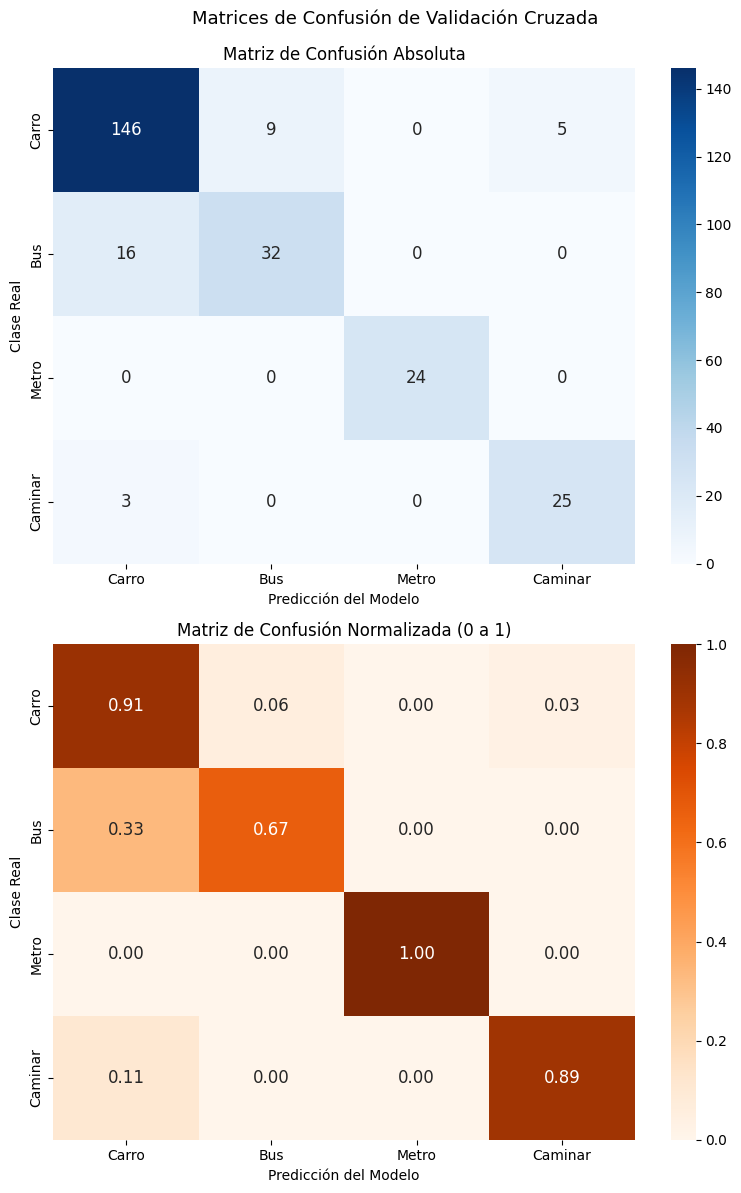

In [6]:
# 5. Evaluación de Producción mediante GroupKFold (5 Splits) por caid_trip
MODOS = ["Carro", "Bus", "Metro", "Caminar"]
MODE_TO_IDX = {m.lower(): i for i, m in enumerate(MODOS)}

X = df_features[feature_cols_v4].fillna(0.0)
y = df_features["label"].map(MODE_TO_IDX)
groups = df_features["caid_trip"]

gkf = GroupKFold(n_splits=5)
oof_preds = np.zeros(len(df_features))

for train_idx, val_idx in gkf.split(df_features, y, groups):
    df_train = df_features.iloc[train_idx].fillna(0.0)
    df_val = df_features.iloc[val_idx].fillna(0.0)
    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]
    
    # N1: Caminar vs Motorizado
    clf_n1 = RandomForestClassifier(**RF_HYPERPARAMETERS["n1"])
    clf_n1.fit(df_train[feature_cols_v4], (y_train != MODE_TO_IDX["caminar"]).astype(int))
    
    # N2: Metro vs Superficie
    motor_mask = (y_train != MODE_TO_IDX["caminar"])
    clf_n2 = RandomForestClassifier(**RF_HYPERPARAMETERS["n2"])
    clf_n2.fit(df_train[motor_mask][feature_cols_v4], (y_train[motor_mask] == MODE_TO_IDX["metro"]).astype(int))
    
    # N3: Carro vs Bus
    road_mask = (y_train == MODE_TO_IDX["carro"]) | (y_train == MODE_TO_IDX["bus"])
    clf_n3 = RandomForestClassifier(**RF_HYPERPARAMETERS["n3"])
    clf_n3.fit(df_train[road_mask][feature_cols_v4], (y_train[road_mask] == MODE_TO_IDX["bus"]).astype(int))
    
    pred_n1 = clf_n1.predict(df_val[feature_cols_v4])
    pred_n2 = clf_n2.predict(df_val[feature_cols_v4])
    pred_n3 = clf_n3.predict(df_val[feature_cols_v4])
    
    for i, idx_val in enumerate(val_idx):
        if pred_n1[i] == 0:
            oof_preds[idx_val] = MODE_TO_IDX["caminar"]
        else:
            if pred_n2[i] == 1:
                oof_preds[idx_val] = MODE_TO_IDX["metro"]
            else:
                oof_preds[idx_val] = MODE_TO_IDX["bus"] if pred_n3[i] == 1 else MODE_TO_IDX["carro"]

acc = balanced_accuracy_score(y, oof_preds)
f1 = f1_score(y, oof_preds, average="macro")
print(f"Balanced Accuracy Global: {acc*100:.2f}%")
print(f"Macro F1-Score: {f1*100:.2f}%")

print("\n--- MATRIZ DE CONFUSIÓN ---")
cm = confusion_matrix(y, oof_preds)
print(pd.DataFrame(cm, index=[f"Real {m}" for m in MODOS], columns=[f"Pred {m}" for m in MODOS]))

print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y, oof_preds, target_names=MODOS))

# Visualización de matrices de confusión (Absoluta y Normalizada)
import matplotlib.pyplot as plt
try:
    import seaborn as sns
    sns_available = True
except ImportError:
    sns_available = False

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
fig, axes = plt.subplots(2, 1, figsize=(8, 12))

if sns_available:
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=[m.capitalize() for m in MODOS],
                yticklabels=[m.capitalize() for m in MODOS],
                cbar=True, annot_kws={"size": 12}, ax=axes[0])
else:
    im0 = axes[0].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    fig.colorbar(im0, ax=axes[0])
    tick_marks = np.arange(len(MODOS))
    axes[0].set_xticks(tick_marks)
    axes[0].set_xticklabels([m.capitalize() for m in MODOS], rotation=45)
    axes[0].set_yticks(tick_marks)
    axes[0].set_yticklabels([m.capitalize() for m in MODOS])
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[0].text(j, i, format(cm[i, j], 'd'),
                         horizontalalignment="center",
                         color="white" if cm[i, j] > thresh else "black")
axes[0].set_ylabel('Clase Real')
axes[0].set_xlabel('Predicción del Modelo')
axes[0].set_title('Matriz de Confusión Absoluta')

if sns_available:
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Oranges", vmin=0.0, vmax=1.0,
                xticklabels=[m.capitalize() for m in MODOS],
                yticklabels=[m.capitalize() for m in MODOS],
                cbar=True, annot_kws={"size": 12}, ax=axes[1])
else:
    im1 = axes[1].imshow(cm_norm, interpolation='nearest', cmap=plt.cm.Oranges, vmin=0.0, vmax=1.0)
    fig.colorbar(im1, ax=axes[1])
    tick_marks = np.arange(len(MODOS))
    axes[1].set_xticks(tick_marks)
    axes[1].set_xticklabels([m.capitalize() for m in MODOS], rotation=45)
    axes[1].set_yticks(tick_marks)
    axes[1].set_yticklabels([m.capitalize() for m in MODOS])
    thresh = 0.5
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            axes[1].text(j, i, format(cm_norm[i, j], '.2f'),
                         horizontalalignment="center",
                         color="white" if cm_norm[i, j] > thresh else "black")
axes[1].set_ylabel('Clase Real')
axes[1].set_xlabel('Predicción del Modelo')
axes[1].set_title('Matriz de Confusión Normalizada (0 a 1)')

plt.suptitle('Matrices de Confusión de Validación Cruzada', fontsize=13, y=0.99)
plt.tight_layout()
plt.show()

In [7]:
# 6. Guardrail de Calidad de Producción
def validate_quality_guardrail(num_pings, pct_conserved):
    """Devuelve True si cumple calidad, False de lo contrario."""
    if num_pings < MIN_EFFECTIVE_PINGS:
        return False, "Calidad insuficiente (pings efectivos < 15)"
    if pd.isna(pct_conserved):
        return False, "Calidad insuficiente (porcentaje conservado no disponible)"
    if pct_conserved < MIN_PCT_CONSERVED:
        return False, "Calidad insuficiente (porcentaje conservado < 30%)"
    return True, "Calidad Aceptable"

# Ejemplo de simulación del guardrail
test_cases = [
    {"num_pings": 50, "pct_conserved": 99.0},
    {"num_pings": 5, "pct_conserved": 99.0},
    {"num_pings": 40, "pct_conserved": 20.0}
]

for tc in test_cases:
    passed, msg = validate_quality_guardrail(tc["num_pings"], tc["pct_conserved"])
    print(f"Caso {tc} -> Aprobado: {passed} | Mensaje: {msg}")

Caso {'num_pings': 50, 'pct_conserved': 99.0} -> Aprobado: True | Mensaje: Calidad Aceptable
Caso {'num_pings': 5, 'pct_conserved': 99.0} -> Aprobado: False | Mensaje: Calidad insuficiente (pings efectivos < 15)
Caso {'num_pings': 40, 'pct_conserved': 20.0} -> Aprobado: False | Mensaje: Calidad insuficiente (porcentaje conservado < 30%)


In [8]:
# 7. Simulación de Inferencia Oficial con Guardrail
def run_live_inference(trip_row, model_dict):
    # 1. Validar calidad
    passed, msg = validate_quality_guardrail(trip_row["num_pings"], trip_row["pct_conserved"])
    if not passed:
        return None, msg
        
    # 2. Inferencia en cascada
    clf_n1 = model_dict["clf_n1"]
    clf_n2 = model_dict["clf_n2"]
    clf_n3 = model_dict["clf_n3"]
    feature_cols = model_dict["feature_cols_v4"]
    
    feat_vec = pd.DataFrame([trip_row])[feature_cols].fillna(0.0)
    
    pred_n1 = clf_n1.predict(feat_vec)[0]
    if pred_n1 == 0:
        return "Caminar", "Predicción exitosa"
    else:
        pred_n2 = clf_n2.predict(feat_vec)[0]
        if pred_n2 == 1:
            return "Metro", "Predicción exitosa"
        else:
            pred_n3 = clf_n3.predict(feat_vec)[0]
            final_mode = "Bus" if pred_n3 == 1 else "Carro"
            return final_mode, "Predicción exitosa"

# Cargar el modelo final entrenado de producción
prod_model_path = PROJECT_ROOT / "Inputs" / "GPS User Data" / "random_forest_modal.pkl"
with open(prod_model_path, "rb") as f:
    model_dict = pickle.load(f)
    
# Ejecutar sobre la primera fila del dataset
sample_row = df_features.iloc[0].to_dict()
mode, msg = run_live_inference(sample_row, model_dict)
print(f"Inferencia sobre viaje {sample_row['caid_trip']} -> Modo Predicho: {mode} | Estado: {msg}")

Inferencia sobre viaje AAF_1 -> Modo Predicho: None | Estado: Calidad insuficiente (porcentaje conservado < 30%)
